# RAF-DB Dataset Exploration

## 1 Overview

This notebook analyses and prepares the Real-world Affective Faces Database (RAF-DB) to evaluate pre-trained facial-expression recognition models. RAF-DB contains facial images with emotional expression labels. The data set will only be used to evaluate the model and will not be used for training a new model.

The inspection checks the dataset structure, image files, emotion labels, class distribution, missing data, and invalid images. Any necessary cleanup will be performed without changing the original files stored in the raw data folder.

## 2 Importing Libraries

Following libraries have been used for managing file paths, structuring label information and inspection of images. pathlib handles folders and files, pandas handles tabular data and Pillow is used to check that image files are readable correctly.

In [1]:
# Importing Libraries
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import hashlib

## 3 Loading Dataset

RAF-DB has been split into training and test sets separately. Each set contains a CSV file with the image information and the assigned emotion label. The files are loaded separately to maintain the original evaluation split.

In [2]:
# dataset folder
path = Path("../../data/raw/raf_db")
dataset_folder = path / "DATASET"

In [3]:
# train and test folders
train_folder = dataset_folder / "train"
test_folder = dataset_folder / "test"

In [4]:
# train and test labels
train_labels = path / "train_labels.csv"
test_labels = path / "test_labels.csv"

In [5]:
# train and test dataframe
train_df = pd.read_csv(train_labels)
test_df = pd.read_csv(test_labels)

In [6]:
# printing training and testing records
print("Training records:", len(train_df))
print("Testing records:", len(test_df))

Training records: 12271
Testing records: 3068


In [7]:
# head of training data
train_df.head()

,image,label
0,train_00001_aligned.jpg,5
1,train_00002_aligned.jpg,5
2,train_00003_aligned.jpg,4
3,train_00004_aligned.jpg,4
4,train_00005_aligned.jpg,5


In [8]:
# head of testing data
test_df.head()

,image,label
0,test_0001_aligned.jpg,5
1,test_0002_aligned.jpg,1
2,test_0003_aligned.jpg,4
3,test_0004_aligned.jpg,1
4,test_0005_aligned.jpg,5


The RAF-DB training and testing label files were successfully loaded into DataFrames. The original dataset split was maintained and the records shown confirm that each one contains an image filename and a corresponding numeric emotion label. These records will be used to locate and study the facial images in the following section.

## 4 Sample Images

The first five images from the test set are shown with their numeric labels. This confirms that the filenames in the CSV file correctly correspond to the images stored within the class folders. It also gives a first visual impression on the facial images before further dataset inspection.

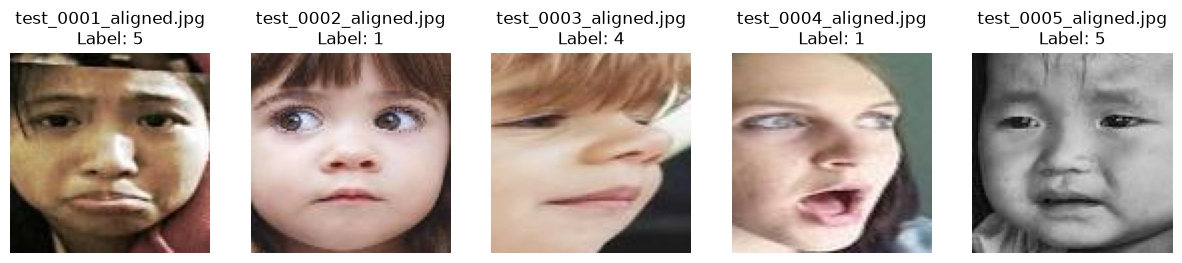

In [9]:
# first five testing records
sample = test_df.head(5)

# space for five images
figure, axes = plt.subplots(1, 5, figsize=(15, 4))

# each image with label
for axis, (_, row) in zip(axes, sample.iterrows()):
    filename = row["image"]
    label = row["label"]
    # image path
    image_path = test_folder / str(label) / filename
    image = Image.open(image_path).convert("RGB")
    # axis
    axis.imshow(image)
    axis.set_title(f"{filename}\nLabel: {label}")
    axis.axis("off")

plt.show()

The first five photos from the test set are shown with their number labels. This confirms that the filenames in the CSV file appropriately correspond to the photographs contained within the class folders. It also gives a first visual impression on the facial images before additional dataset inspection.

## 5 Mapping Emotion Labels

RAF-DB contains seven basic facial-expression classes which are surprise, fear, disgust, happiness, sadness, anger and neutral [1]. The numbers 1 to 7 are used to store the RAF-DB labels. To make the dataset results easier to understand during inspection and model evaluation, these numbers are translated into names of emotions.

In [10]:
# each numerical label with its emotion name
emotion_labels = {
    1: "Surprise",
    2: "Fear",
    3: "Disgust",
    4: "Happiness",
    5: "Sadness",
    6: "Anger",
    7: "Neutral"
}

In [11]:
# emotion names
train_df["emotion"] = train_df["label"].map(emotion_labels)
test_df["emotion"] = test_df["label"].map(emotion_labels)

In [12]:
# Training data
train_df.head()

,image,label,emotion
0,train_00001_aligned.jpg,5,Sadness
1,train_00002_aligned.jpg,5,Sadness
2,train_00003_aligned.jpg,4,Happiness
3,train_00004_aligned.jpg,4,Happiness
4,train_00005_aligned.jpg,5,Sadness


In [13]:
# Testing data
test_df.head()

,image,label,emotion
0,test_0001_aligned.jpg,5,Sadness
1,test_0002_aligned.jpg,1,Surprise
2,test_0003_aligned.jpg,4,Happiness
3,test_0004_aligned.jpg,1,Surprise
4,test_0005_aligned.jpg,5,Sadness


Meaningful emotion names were successfully created from the numerical labels. This preserves the original numerical labels for future model evaluation while making the dataset easier to understand.

## 6 Class Distribution

### 6.1 Count of Images

For the training and testing sets, the quantity of photos associated with each emotion is counted. This checks whether certain emotions have significantly more photos than others, which could have an impact on model performance and the selection of assessment criteria.

In [14]:
# Count images each emotion class
train_counts = train_df["emotion"].value_counts()
test_counts = test_df["emotion"].value_counts()

In [15]:
# Combine the counts into one table
class_distribution = pd.DataFrame({
    "Training Images": train_counts,
    "Testing Images": test_counts
}).fillna(0).astype(int)

In [16]:
class_distribution

,Training Images,Testing Images
emotion,,
Anger,705,162
Disgust,717,160
Fear,281,74
Happiness,4772,1185
Neutral,2524,680
Sadness,1982,478
Surprise,1290,329


### 6.2 Visualisation

To help with the identification of differences between the emotion classifications, bar charts are used.

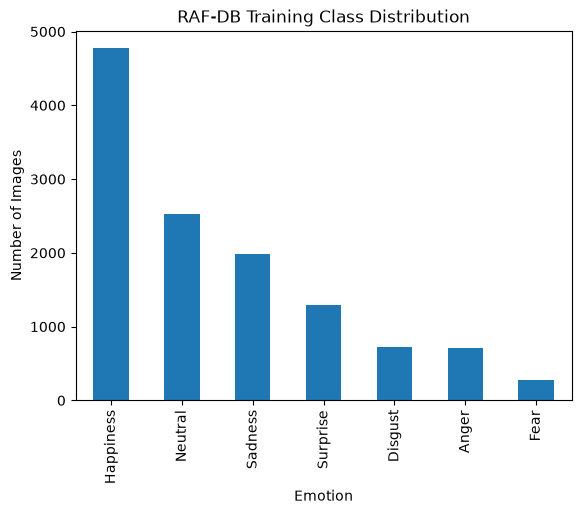

In [17]:
# bar chart for the training data
train_counts.plot(kind="bar")
plt.title("RAF-DB Training Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.show()

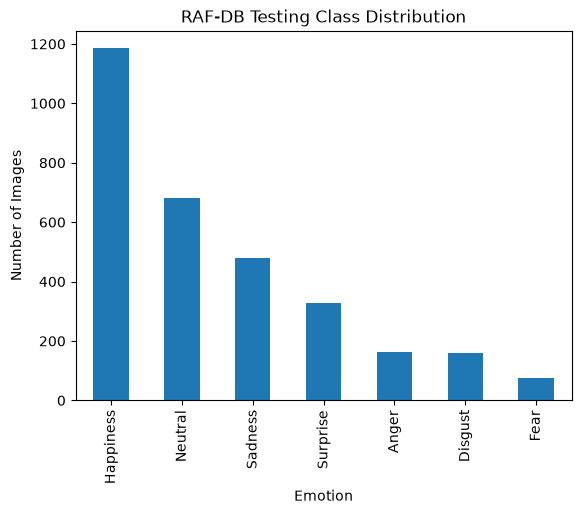

In [18]:
# bar chart for the testing data
test_counts.plot(kind="bar")
plt.title("RAF-DB Testing Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.show()

The seven emotion classes have different numbers of images, showing that RAF-DB is not entirely balanced. Because accuracy alone may favor larger classes, this is important when evaluating the model. In order to give an equal comparison between the facial-expression models, macro-F1 and per-class precision and recall will thereafter be used.

## 7 Checking Label Data

Duplicate image filenames, invalid emotion labels, and missing values are examined in the training and testing label files. These checks help in ensuring that repeated or incomplete records do not impact the evaluation findings.

In [19]:
# missing values in train_df
train_df.isnull().sum().to_frame("Missing Values")

,Missing Values
image,0
label,0
emotion,0


In [20]:
# missing values in test_df
test_df.isnull().sum().to_frame("Missing Values")

,Missing Values
image,0
label,0
emotion,0


In [21]:
# valid labels
valid_labels = [1, 2, 3, 4, 5, 6, 7]

In [22]:
# check for invalid labels
invalid_train = train_df[~train_df["label"].isin(valid_labels)]
invalid_train

,image,label,emotion


In [23]:
invalid_test = test_df[~test_df["label"].isin(valid_labels)]
invalid_test

,image,label,emotion


In [24]:
# checking for duplicates in train data
train_duplicates = train_df["image"].duplicated().sum()
train_duplicates

np.int64(0)

In [25]:
# checking for duplicates in test data
test_duplicates = test_df["image"].duplicated().sum()
test_duplicates

np.int64(0)

No missing values, invalid labels and duplicated records were found in the dataset. Before the corresponding image files are examined, these tests verify whether the CSV records are appropriate for reliable model evaluation. 

## 8 Checking Image Files

Every CSV entry pointing to an existing, readable image within the appropriate emotion folder is verified by checking the image files. This keeps the model evaluation from being impacted by missing or corrupted files.

In [26]:
# Lists for recording image problems training data
missing_train_images = []
invalid_train_images = []

In [27]:
# Check every training image
for _, row in train_df.iterrows():
    # image path
    image_path = train_folder / str(row["label"]) / row["image"]
    # if image path does not exist
    if not image_path.exists():
        missing_train_images.append(row["image"])
    else:
        try:
            # open the image and verify
            with Image.open(image_path) as image:
                image.verify()
        except Exception:
            # error 
            invalid_train_images.append(row["image"])

In [28]:
# printing statements
print("Missing training images:", len(missing_train_images))
print("Invalid training images:", len(invalid_train_images))

Missing training images: 0
Invalid training images: 0


In [29]:
# Lists for recording image problems for testing data
missing_test_images = []
invalid_test_images = []

In [30]:
# Check every testing image
for _, row in test_df.iterrows():
    image_path = test_folder / str(row["label"]) / row["image"]
    # if image path does not exist
    if not image_path.exists():
        missing_test_images.append(row["image"])
    else:
        try:
            # open the image and verify
            with Image.open(image_path) as image:
                image.verify()
        except Exception:
            # error
            invalid_test_images.append(row["image"])

In [31]:
# printing statements
print("Missing testing images:", len(missing_test_images))
print("Invalid testing images:", len(invalid_test_images))

Missing testing images: 0
Invalid testing images: 0


Every training and testing image is successfully opened and was located in the appropriate emotion files. Consequently, the RAF-DB dataset is appropriate for assessing the pre-trained vision models, and no image records had to be deleted.

## 9 Checking Image Properties

To determine the image size, color mode, and file format, a sample of RAF-DB images is examined. This helps in figuring out what preprocessing the candidate vision models need.

In [32]:
# image properties
properties = []

In [33]:
# sample paths
sample_paths = []

In [34]:
for folder in [train_folder, test_folder]:
    for class_folder in sorted(folder.iterdir()):
        if class_folder.is_dir():
            # sample path extend get the jpg pictures
            sample_paths.extend(list(class_folder.glob("*.jpg"))[:5])

In [35]:
for image_path in sample_paths:
    # open image
    with Image.open(image_path) as image:
        # append
        properties.append({
            "Width": image.width,
            "Height": image.height,
            "Colour Mode": image.mode,
            "Format": image.format
        })

In [36]:
# dataframe
df_properties = pd.DataFrame(properties)
df_properties.value_counts().reset_index(name="Number of Sample Images")

,Width,Height,Colour Mode,Format,Number of Sample Images
0,100,100,RGB,JPEG,70


The dimensions, color mode, and file format of the sampled RAF-DB images were examined. Later on in the vision-model evaluation process, model-specific scaling and normalisation will be implemented.

## 10 Conclusion

Before model evaluation, RAF-DB was examined. The class distribution was analysed, sample photos were shown, numerical labels were translated into emotion names, and the training and testing divides were maintained. While the picture files were examined for missing or unreadable data, the label files were also examined for duplicate filenames, invalid labels, and missing values.

Since the dataset will only be used to assess pre-trained models, no training related processing, such as augmentation or class balance, was carried out. Any model specific normalization and resizing will be implemented subsequently according with each future vision model's specifications.

## References
[1] S. Li, W. Deng, and J. Du, "Reliable crowdsourcing and deep locality-preserving learning for
expression recognition in the wild," 2017. [Online]. Available:
https://ieeexplore.ieee.org/document/8099760. [Accessed: Jun 21, 2026].